In [1]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import os
import glob
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Welcome to JupyROOT 6.26/16


In [10]:
#Big set of functions -- all the current ClusterToGraph label assignment logic:

def AddInfo(dbscan_hits, const_hit_array, edep_events):
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    dbscan_cluster_list = []
    spills_in_file = np.unique(dbscan_hits[:,-4])
    iter_ = 0
    preemption_counter = []
    for spill_number in range(3): #spills_in_file:
        spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
        segments_in_spill = np.unique(spill_level[:,-2])
        for segment_number in segments_in_spill:
            time_segment_level = spill_level[spill_level[:,-2] == segment_number]
            clusters_in_segment = np.unique(time_segment_level[:,-1])
            for cluster_number in clusters_in_segment:
                dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
                rows = []
                #alright, for each hit can pull the m-nn, m-hn. 
                expected_hits = len(dbscan_cluster_level)
                preemptions_in_cluster = 0
                for i, hit in enumerate(dbscan_cluster_level):
                    #assign refs 
                    m_nn = hit[0]
                    m_hn = hit[1]
                    ref_nn = m_nn
                    ref_hn = m_hn
                
                    #grab the const hit array
                    const_hit_array_nn = const_hit_array[const_hit_array[:,0] == m_nn]
                    const_hit_info = const_hit_array_nn[const_hit_array_nn[:,1] == m_hn]
                
                    #pull the default information. 
                    edep_events.GetEntry(int(m_nn)) #assign the event. Gets called at least once per hit.  
                    #print(f'{m_nn} and {m_hn}')
                    default_hit_segment = (event.SegmentDetectors['volTMS'])[int(m_hn)] #only pull one segment not all.
                    default_trackid = (default_hit_segment.Contrib)[0]
                    default_pdgid = ((event.Trajectories)[default_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in. 

                    #ok now we have the defaults. Two paths:

                    #If our pdgid is != 13, AND we have constituent hits to scan over, then lets scan over them.
                    if (abs(default_pdgid) != 13) and (np.shape(const_hit_info)[0] > 1):
                        #loop over the constituent hit nns, want to limit get entry calls
                        Replaced = False #monitors state, helps us break early or make sure to add our row at the end of no replacement is found. 
                        for constituent_hit_nn in np.unique(const_hit_info[:,2]):
                            #we have to loop over neutrino number since we have instances of merged hits w/ multiple neutrino events. 
                            #check state, and if it has already been replaced, continue no further. 
                            if Replaced == True:
                                break
                            edep_events.GetEntry(int(constituent_hit_nn)) #set the event. 
                            const_nn_sub_array = const_hit_info[const_hit_info[:,2] == constituent_hit_nn ] #grab the constituent hits w/ the desired neutrino number
                            for const_hit in const_nn_sub_array:
                                #another check of state!
                                if Replaced == True:
                                    break
                                
                                const_hit_number = const_hit[-1]
                                const_hit_segment = (event.SegmentDetectors['volTMS'])[int(const_hit_number)] #only pull one segment not all.
                                const_trackid = (const_hit_segment.Contrib)[0]
                                const_pdgid = ((event.Trajectories)[const_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in.
                            
                                #ok, so we've found an instance of a constituent w/ a pdgid of 13! Let's save our row. 
                                if (abs(const_pdgid) == 13):
                                    Replaced = True #set the state so no multiple replacements.
                                    new_row = np.array((constituent_hit_nn, const_hit_number, hit[4], hit[2], hit[6], const_trackid, const_pdgid))
                                    preemptions_in_cluster += 1
                                    rows.append(new_row)
                                    iter_ +=1 

                        #say we have loop over all constituents and found no muons, despite there being constituents, means our Replaced will still be False
                        if (Replaced == False):
                            #if found no replacement despite not being a muon by default, and having constituents, just append the defaults. 
                            new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                            rows.append(new_row)
                            iter_ +=1 
    
                    #Else -> Ie, our pdgid == 13, OR our pdgid != 13 but there is only 1 constituent hit, nothing to scan over, just save what we have as default. 
                    else:
                        new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                        rows.append(new_row)
                        iter_ +=1

                    if (iter_ % 1000 == 0):
                        print(f'Added info through - {iter_}')

                preemption_counter.append(preemptions_in_cluster) #append the total number of preempted hits, will count by cluster

                #add to our running list, now grouped by cluster. 
                infod_hits = len(rows)
                if infod_hits != expected_hits:
                    print(f"Iter - {iter}, Expected {expected_hits}, got {infod_hits} - something is wrong!")
                dbscan_hits_with_info = np.vstack(rows)
                dbscan_cluster_list.append(dbscan_hits_with_info)
                
    return(dbscan_cluster_list, preemption_counter)


#our labeling logic. 
def AssignLabels_3gen(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
    
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
          
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
       
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
    
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

def AssignLabels_2gen(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
    
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
                
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
                """
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
                """
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

def AssignLabels_1gen(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
    
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
                """
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
       
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
                """
    
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

def AssignLabels_0gen(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
            """
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
                
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
       
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
                """
    
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

def RemoveDuplicates(labeled_slices_):
    filtered_slices = []
    for slice_labeled in labeled_slices_:
        zx = slice_labeled[:,[0,1]]
        unique_entries, unique_indices, inverse = np.unique(zx, axis=0, return_index = True, return_inverse = True)
        filtered_ = []
        for group_id in range(len(unique_indices)):
            group_indices = np.where(inverse == group_id)[0] #grabbing indices of the actual locations in the slices labeled array using inverse
            group = slice_labeled[group_indices]
            
            if len(np.unique(group[:,-1])) > 1: #if this is the case we have both tracks and others in a group, grab tracks and append the first. 
                track_instances = group[group[:,-1] == 0]
                #could be multiple instances. Append the first one.
                filtered_.append(track_instances[0])
                
            else: #if this is the case we have only showers or tracks in the group. There may be internal duplicated but we don't care and just grab first instance. 
                filtered_.append(group[0])

        filtered_slices.append((np.vstack(filtered_)))
        
    return(filtered_slices)

In [ ]:
#Let's workshop this function to move away from delaunay and towards fully connected. 
def CreateGraphList(graph_points_list_, file_number, occupancy_): #takes an argument of a list of arrays containing the nodes for each cluster properly formatted
    graph_list = [] #list of torch graph objects
    for i, graph_points in enumerate(graph_points_list_):
        dbscan_cluster_object = graph_points #initialize our dbscan cluster.
        #create our graph nodes and features
        node_positions = np.asarray(dbscan_cluster_object[:, 0:2], dtype=float)
        node_features = dbscan_cluster_object[:,0:3]
        #node feature vector (z,x,PE)
        feature_vector = torch.tensor((node_features), dtype = torch.float)
        node_semantic_labels = torch.tensor((dbscan_cluster_object[:,3]), dtype = torch.long)

        #check min 3 points, max 1000 (this is kinda just an estimate for high end)
        if np.shape(dbscan_cluster_object)[0] < 3 or np.shape(dbscan_cluster_object)[0] > 1000:
            continue

        #check for enough distinct points to form a triangle
        unique_xs = np.unique(dbscan_cluster_object[:,1])
        unique_zs = np.unique(dbscan_cluster_object[:,0])
        if len(unique_xs) < 2 or len(unique_zs) < 2:
            continue

        
        #try-except block as a final filter for failed graphs 
        try:
            tri = Delaunay(node_positions)
        except Exception as e:
            print(f"Skipping cluster {i} due to Delaunay error: {e}")
            continue
        edges = set()
        
        for simplex in tri.simplices:
            for j in range(3):
                #indexes like (u,v) where u and v are the indexes of the points making up the edge
                u = simplex[j]
                v = simplex[(j + 1) % 3] 
                edges.add((u,v)) 
                edges.add((v,u)) #we want to add both directions, since undirected.       

        edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous() #need to transpose since torch expects EdgeIndex like [2, # edges], we produced [# edges, 2] contiguous is a memory flag for gpu opt. 
        #now we can package into a Data object for PyG
        graph_data = Data( x = feature_vector, edge_index = edge_index, y = node_semantic_labels)
        
        #file number along with graph number allow us to traceback to original dbscan cluster from graph later on
        graph_data.file_number = torch.tensor(file_number, dtype=torch.long)
        graph_data.graph_number = torch.tensor(i, dtype=torch.long)
        #adding the occupancy, facilitates quick analysis of accuracy as a function of occupancy.
        graph_data.occupancy = torch.tensor(occupancy_[i], dtype=torch.long)
        
        graph_list.append(graph_data)

    return(graph_list)

In [6]:
#Script focused followups to the 8/8 TMS meeting. 
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
const_hit_array = merged_hits_file['third']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002530.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [11]:
%%time
dbscan_cluster_list_, preemption_count_per_cluster = AddInfo(dbscan_hits, const_hit_array, edep_events)

Added info through - 1000
Added info through - 2000
Added info through - 3000
Added info through - 4000
Added info through - 5000
Added info through - 6000
Added info through - 7000
Added info through - 8000
Added info through - 9000
Added info through - 10000
Added info through - 11000
Added info through - 12000
Added info through - 13000
Added info through - 14000
Added info through - 15000
Added info through - 16000
Added info through - 17000
Added info through - 18000
Added info through - 19000
Added info through - 20000
Added info through - 21000
Added info through - 22000
Added info through - 23000
CPU times: user 5min 1s, sys: 3.01 s, total: 5min 4s
Wall time: 5min 6s


In [12]:
len(preemption_count_per_cluster)

694

array([ 0, 15,  0,  7,  1,  1,  0,  7,  1,  5,  0,  0,  2, 17,  4,  0,  6,
        6,  3,  0, 28,  0, 12,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  6,  0,  0,  0,  6,  3,  0,  3,  1,  0, 17,  1,  0,  4,  1,
        0,  0, 16,  0,  0,  0,  1,  0,  0,  4,  2,  0,  1,  0,  0,  6,  0,
        0,  0,  0,  0,  0,  4,  0, 16,  0,  0,  6,  0,  2,  0,  2,  0,  1,
        0,  5,  0,  6,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  3,  0,  0,
        6,  0,  4,  0,  4,  1,  0,  1,  0,  0,  4,  0,  0,  0,  0,  0,  0,
        5,  9,  0,  0,  0,  0,  0,  2,  0,  2,  1,  0,  0,  0,  0,  3,  0,
        0,  0,  0,  2,  6,  1,  0,  6,  0,  0,  0,  0,  2,  3,  0,  2, 12,
        0,  7,  0,  0,  0,  7,  0,  0,  2,  0, 17,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  3,  0,  0,  6,  0,  0,  2,  0,  0,  6,
        0,  7,  0,  7,  0,  0,  4,  0, 19,  0,  0,  0,  0,  0,  0,  1,  0,
       10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

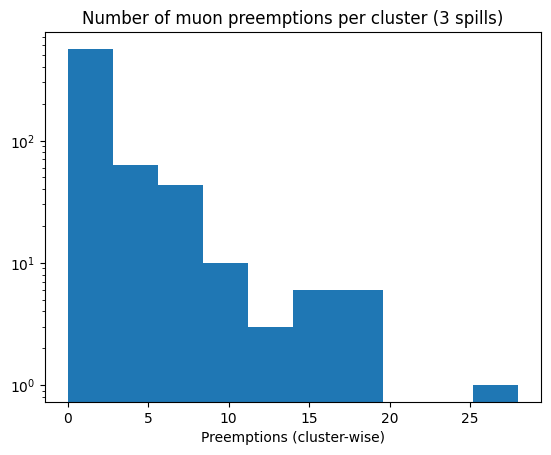

In [17]:
plt.hist(preemption_count_per_cluster)
plt.yscale('log')
plt.xlabel('Preemptions (cluster-wise)')
plt.title('Number of muon preemptions per cluster (3 spills)')

In [26]:
preemption_array = np.array(preemption_count_per_cluster)
len(preemption_array[preemption_array > 4]) / len(preemption_array)

0.12247838616714697

In [48]:
%%time
#We will need the DBSCAN clusters w/ preemption in any case - will be making changes to the second part of the labeling logic:
#Lets compare labels for a scheme with 3 generation track merging and one with only parent merging.
graph_points_list_3gen = RemoveDuplicates(AssignLabels_3gen(dbscan_cluster_list_, edep_events))

Assigned labels through 0
Assigned labels through 100
Assigned labels through 200
Assigned labels through 300
Assigned labels through 400
Assigned labels through 500
Assigned labels through 600
CPU times: user 2min 1s, sys: 2.02 s, total: 2min 3s
Wall time: 2min 4s


In [50]:
%%time
graph_points_list_1gen = RemoveDuplicates(AssignLabels_1gen(dbscan_cluster_list_, edep_events))

Assigned labels through 0
Assigned labels through 100
Assigned labels through 200
Assigned labels through 300
Assigned labels through 400
Assigned labels through 500
Assigned labels through 600
CPU times: user 2min 1s, sys: 2.02 s, total: 2min 3s
Wall time: 2min 4s


In [52]:
graph_points_list_2gen = RemoveDuplicates(AssignLabels_2gen(dbscan_cluster_list_, edep_events))

Assigned labels through 0
Assigned labels through 100
Assigned labels through 200
Assigned labels through 300
Assigned labels through 400
Assigned labels through 500
Assigned labels through 600


In [51]:
graph_points_list_0gen = RemoveDuplicates(AssignLabels_0gen(dbscan_cluster_list_, edep_events))

Assigned labels through 0
Assigned labels through 100
Assigned labels through 200
Assigned labels through 300
Assigned labels through 400
Assigned labels through 500
Assigned labels through 600


Text(0, 0.5, 'Hit X (mm)')

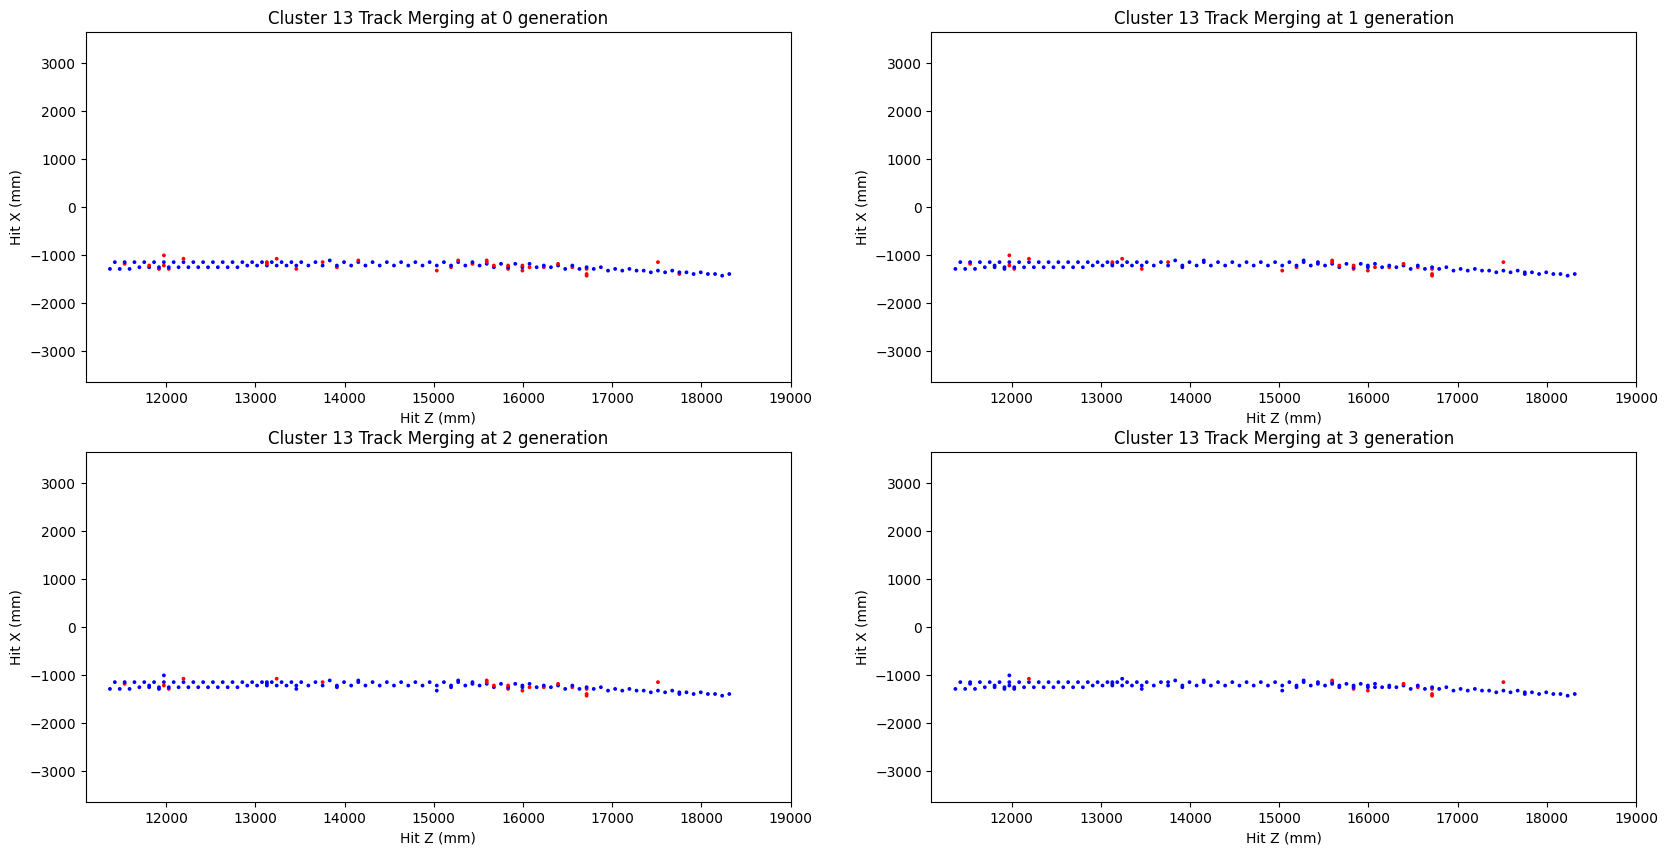

In [124]:
#selected cluster:
cluster_n = 13
hits_labeled_3gen = graph_points_list_3gen[cluster_n]
hits_labeled_2gen = graph_points_list_2gen[cluster_n]
hits_labeled_1gen = graph_points_list_1gen[cluster_n]
hits_labeled_0gen = graph_points_list_0gen[cluster_n]

colors_0gen = []
for hit in hits_labeled_0gen:
    if hit[-1] == 0:
        colors_0gen.append('blue')
    else:
        colors_0gen.append('red')

colors_1gen = []
for hit in hits_labeled_1gen:
    if hit[-1] == 0:
        colors_1gen.append('blue')
    else:
        colors_1gen.append('red')

colors_2gen = []
for hit in hits_labeled_2gen:
    if hit[-1] == 0:
        colors_2gen.append('blue')
    else:
        colors_2gen.append('red')

colors_3gen = []
for hit in hits_labeled_3gen:
    if hit[-1] == 0:
        colors_3gen.append('blue')
    else:
        colors_3gen.append('red')
             
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 10))

sc1 = ax1.scatter(hits_labeled_0gen[:,0], hits_labeled_0gen[:,1], s = 3, c = colors_0gen)
ax1.set_title(f'Cluster {cluster_n} Track Merging at 0 generation')
ax1.set_xlim((11100,19000))
ax1.set_ylim((-3650,3650))
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(hits_labeled_1gen[:,0], hits_labeled_1gen[:,1], s = 3, c = colors_1gen)
ax2.set_title(f'Cluster {cluster_n} Track Merging at 1 generation')
ax2.set_xlim((11100,19000))
ax2.set_ylim((-3650,3650))
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

sc3 = ax3.scatter(hits_labeled_2gen[:,0], hits_labeled_2gen[:,1], s = 3, c = colors_2gen)
ax3.set_title(f'Cluster {cluster_n} Track Merging at 2 generation')
ax3.set_xlim((11100,19000))
ax3.set_ylim((-3650,3650))
ax3.set_xlabel("Hit Z (mm)")
ax3.set_ylabel("Hit X (mm)")

sc4 = ax4.scatter(hits_labeled_3gen[:,0], hits_labeled_3gen[:,1], s = 3, c = colors_3gen)
ax4.set_title(f'Cluster {cluster_n} Track Merging at 3 generation')
ax4.set_xlim((11100,19000))
ax4.set_ylim((-3650,3650))
ax4.set_xlabel("Hit Z (mm)")
ax4.set_ylabel("Hit X (mm)")

In [100]:
#Lets generate some more appreciable statistics, what is the difference in # of hits classified as tracks?
def track_counter(graph_points_list):
    rel_track_hits_list = []
    n_track_hits = 0
    n_graphs_w_tracks = 0
    for graph_points in graph_points_list:
        if len(graph_points[graph_points[:,-1] == 0]) > 0:
            n_graphs_w_tracks +=1
            n_track_hits += len(graph_points[graph_points[:,-1] == 0])
            rel_track_hits_list.append(len(graph_points[graph_points[:,-1] == 0]) / len(graph_points[:,-1]))
            
            
    rel_track_hits_arr = np.array(rel_track_hits_list)

    return(n_track_hits, n_graphs_w_tracks, rel_track_hits_arr)

Text(0, 0.5, 'Avg. Track hits / cluster')

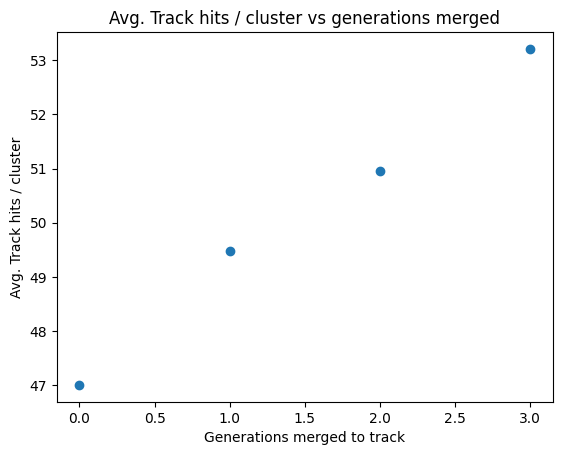

In [101]:
stats_1gen = track_counter(graph_points_list_1gen)
stats_2gen = track_counter(graph_points_list_2gen)
stats_3gen = track_counter(graph_points_list_3gen)
stats_0gen = track_counter(graph_points_list_0gen)
generation = [0,1,2,3]
track_hits = [stats_0gen[0]/stats_0gen[1],stats_1gen[0]/stats_1gen[1], stats_2gen[0]/stats_2gen[1], stats_3gen[0]/stats_3gen[1]]
track_clusters = [stats_0gen[1], stats_1gen[1], stats_2gen[1], stats_3gen[1]]
plt.scatter(generation,track_hits)
plt.title('Avg. Track hits / cluster vs generations merged')
plt.xlabel("Generations merged to track")
plt.ylabel("Avg. Track hits / cluster")

In [102]:
diffs_1gen = stats_1gen[2] - stats_0gen[2]
diffs_2gen = stats_2gen[2] - stats_0gen[2]
diffs_3gen = stats_3gen[2] - stats_0gen[2]

Text(0.5, 0, 'Rel Track Hits Gained via Merging')

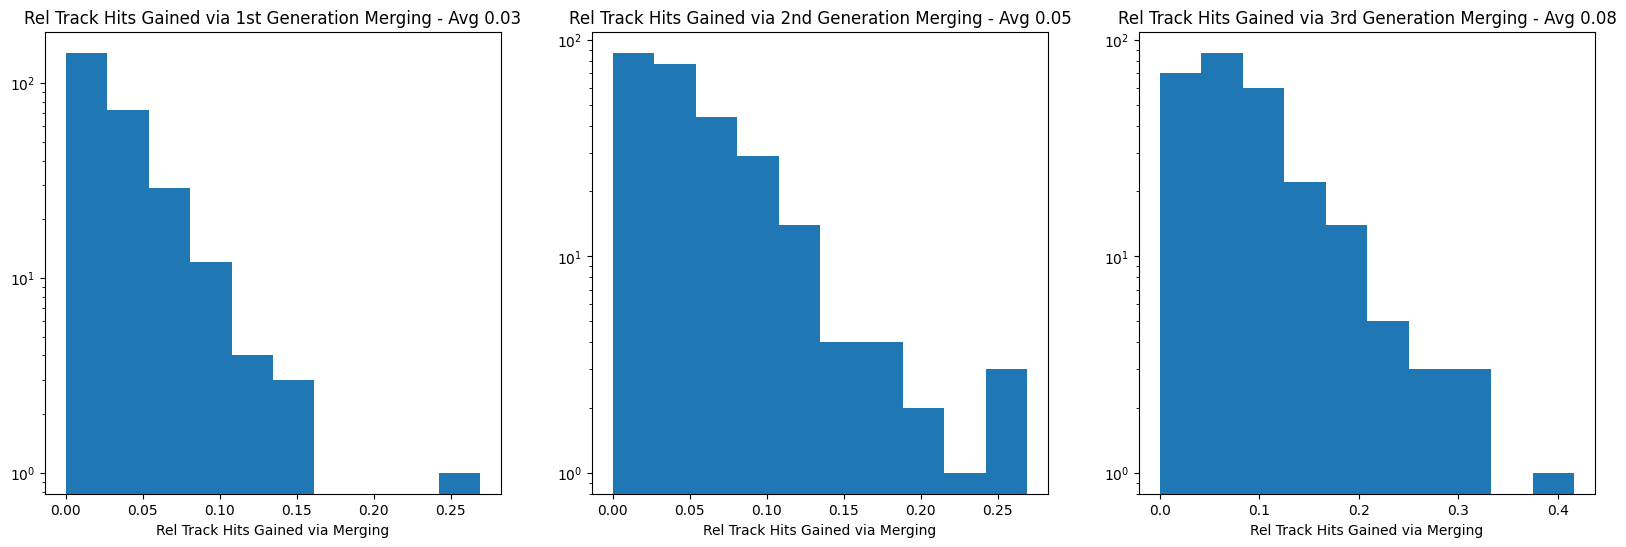

In [107]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

sc1 = ax1.hist(diffs_1gen)
ax1.set_title(f'Rel Track Hits Gained via 1st Generation Merging - Avg {np.mean(diffs_1gen):.2f}')
ax1.set_yscale('log')
ax1.set_xlabel("Rel Track Hits Gained via Merging")

sc2 = ax2.hist(diffs_2gen)
ax2.set_title(f'Rel Track Hits Gained via 2nd Generation Merging - Avg {np.mean(diffs_2gen):.2f}')
ax2.set_yscale('log')
ax2.set_xlabel("Rel Track Hits Gained via Merging")

sc3 = ax3.hist(diffs_3gen)

ax3.set_title(f'Rel Track Hits Gained via 3rd Generation Merging - Avg {np.mean(diffs_3gen):.2f}')
ax3.set_yscale('log')
ax3.set_xlabel("Rel Track Hits Gained via Merging")


In [ ]:
#The simplest way to pull information about the number of nodes and edges is to just load in our test set:

In [27]:
graph_file_directory = '/sdf/data/neutrino/summer25/ktwall/processed/' #directory containing graph datasets.
graph_file_paths = glob.glob(os.path.join(graph_file_directory, "*.pt")) 

In [45]:
validation_file_paths = graph_file_paths[90:95]
validation_datasets_list = []
for validation_path in validation_file_paths:
    validation_datasets_list.append(torch.load(validation_path))

validation_dataset = ConcatDataset(validation_datasets_list)
print('loaded validation dataset')

/lscratch/ktwall/tmp/ipykernel_2282493/3295230368.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  validation_datasets_list.append(torch.load(validation_path))


loaded validation dataset


In [39]:
testing_file_paths = graph_file_paths[95:100]
testing_datasets_list = []
for testing_path in testing_file_paths:
    testing_datasets_list.append(torch.load(testing_path))

testing_dataset = ConcatDataset(testing_datasets_list)
print('loaded testing dataset')

/lscratch/ktwall/tmp/ipykernel_2282493/3611715959.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  testing_datasets_list.append(torch.load(testing_path))


loaded testing dataset


In [46]:
testing_data_loader = DataLoader(testing_dataset, batch_size = 1, drop_last = True, shuffle=True)
print(f'Training on {len(testing_data_loader)*testing_data_loader.batch_size} total graphs')
validation_data_loader = DataLoader(validation_dataset, batch_size = 1, drop_last = True, shuffle=True)
print(f'Validating on {len(validation_data_loader)*validation_data_loader.batch_size} total graphs')

Training on 12516 total graphs
Validating on 12038 total graphs


In [44]:
n_nodes = []
for i, data in enumerate(testing_data_loader):
    n_nodes.append(len(data.x))
    if (i % 1000 == 0):
        print(i)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000


In [47]:
for i, data in enumerate(validation_data_loader):
    n_nodes.append(len(data.x))
    if (i % 1000 == 0):
        print(i)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000


In [ ]:
plt.hist(n_nodes)
plt.yscale('log')
plt.xlabel('Number of Nodes')
plt.title(f'Number of Nodes in Graphs (24k total graphs), mean - {np.mean(n_nodes):.2f}')

Text(0.5, 1.0, 'Number of Nodes in Graphs (24k total graphs), mean - 39.75')